In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/chetankumarg/graduate-record-exam-scores/binary.dta


# Machine Learning Lab – Experiment 2
## Logistic Regression – Graduate Admission Prediction

### Aim
To build a Logistic Regression model to predict whether a student
will be admitted to graduate school using GRE score, GPA, and
University Prestige.

In [31]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


In [32]:
# ============================================
# 2. FIND THE DATASET
# ============================================

import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/chetankumarg/graduate-record-exam-scores/binary.dta


In [33]:
# ============================================
# 3. LOAD DATASET
# ============================================

df = pd.read_stata("/kaggle/input/datasets/chetankumarg/graduate-record-exam-scores/binary.dta")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [34]:
# ============================================
# 4. DATASET INFORMATION
# ============================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (400, 4)

Column Names:
['admit', 'gre', 'gpa', 'rank']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [35]:
# ============================================
# 5. STATISTICAL SUMMARY
# ============================================

display(df.describe(include="all").T)

,count,mean,std,min,25%,50%,75%,max
admit,400.0,0.317500,0.466087,0.00,0.00,0.000,1.00,1.0
gre,400.0,587.700012,115.516663,220.00,520.00,580.000,660.00,800.0
gpa,400.0,3.389900,0.380567,2.26,3.13,3.395,3.67,4.0
rank,400.0,2.485000,0.944462,1.00,2.00,2.000,3.00,4.0


In [36]:
# ============================================
# 6. MISSING VALUE ANALYSIS
# ============================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

display(missing_summary)

,Missing Values,Percentage
admit,0,0.0
gre,0,0.0
gpa,0,0.0
rank,0,0.0


In [37]:
# ============================================
# 7. UNIQUE VALUES
# ============================================

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


admit:
[0. 1.]

gre:
[380. 660. 800. 640. 520. 760. 560. 400. 540. 700. 440. 480. 780. 360.
 500. 600. 680. 620. 580. 460.]

gpa:
[3.61 3.67 4.   3.19 2.93 3.   2.98 3.08 3.39 3.92 3.22 3.44 3.87 2.56
 3.75 3.81 3.17 3.63 2.82 3.35]

rank:
[3. 1. 4. 2.]


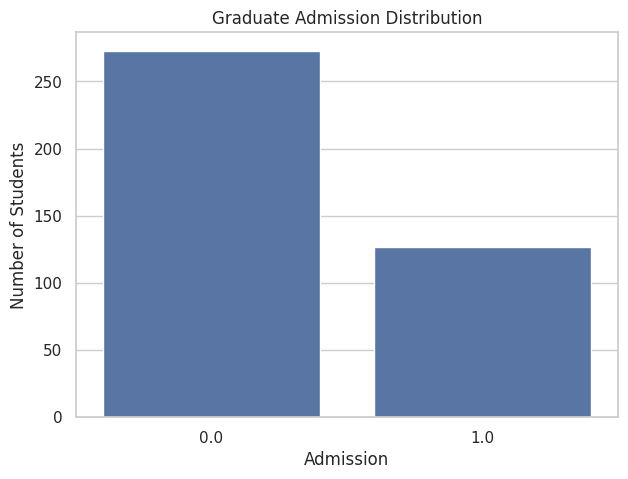

In [38]:
# ============================================
# 8. ADMISSION DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="admit")

plt.title("Graduate Admission Distribution")
plt.xlabel("Admission")
plt.ylabel("Number of Students")

plt.show()

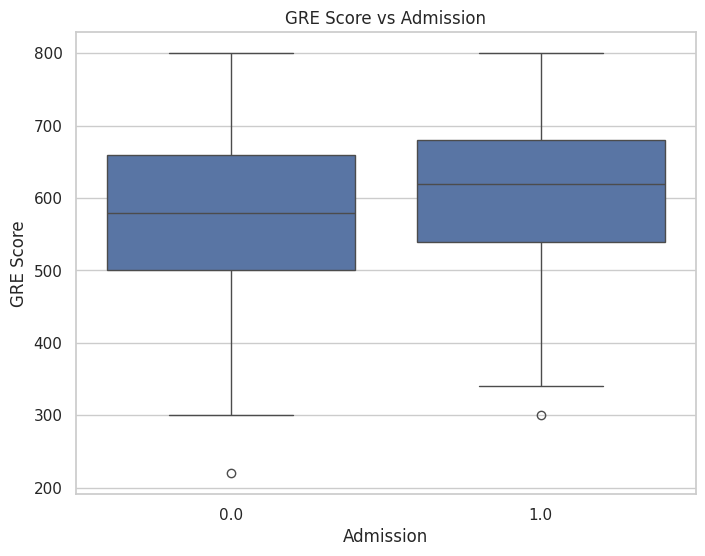

In [39]:
# ============================================
# 9. GRE SCORE VS ADMISSION
# ============================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="admit",
    y="gre"
)

plt.title("GRE Score vs Admission")
plt.xlabel("Admission")
plt.ylabel("GRE Score")

plt.show()

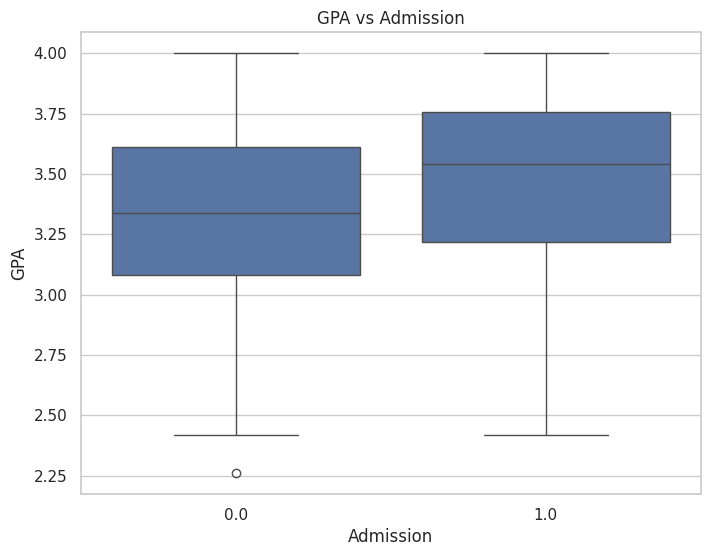

In [40]:
# ============================================
# 10. GPA VS ADMISSION
# ============================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="admit",
    y="gpa"
)

plt.title("GPA vs Admission")
plt.xlabel("Admission")
plt.ylabel("GPA")

plt.show()

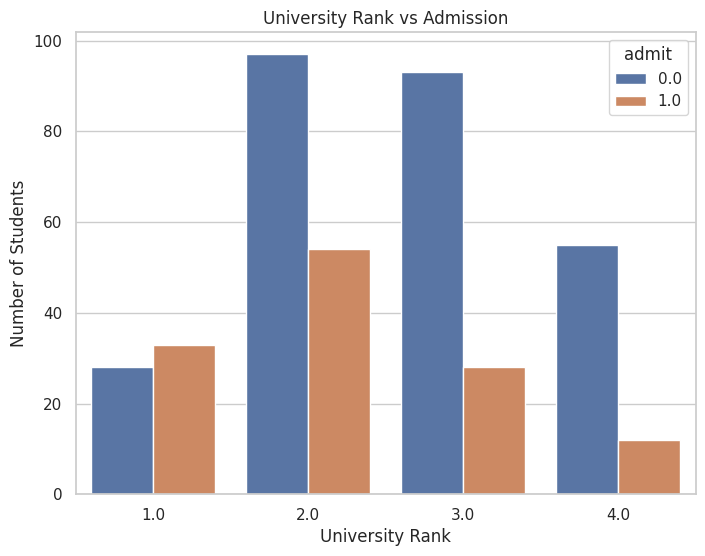

In [41]:
# ============================================
# 11. UNIVERSITY RANK VS ADMISSION
# ============================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="rank",
    hue="admit"
)

plt.title("University Rank vs Admission")
plt.xlabel("University Rank")
plt.ylabel("Number of Students")

plt.show()

In [42]:
# ============================================
# 12. DEFINE FEATURES AND TARGET
# ============================================

X = df[["gre", "gpa", "rank"]]
y = df["admit"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,gre,gpa,rank
0,380.0,3.61,3.0
1,660.0,3.67,3.0
2,800.0,4.00,1.0
3,640.0,3.19,4.0
4,520.0,2.93,4.0



Target:


0    0.0
1    1.0
2    1.0
3    1.0
4    0.0
Name: admit, dtype: float32

In [43]:
# ============================================
# 13. HANDLE MISSING VALUES
# ============================================

print("Missing values before cleaning:")
print(df[["gre", "gpa", "rank", "admit"]].isnull().sum())

model_data = df[["gre", "gpa", "rank", "admit"]].dropna()

X = model_data[["gre", "gpa", "rank"]]
y = model_data["admit"]

print("\nDataset shape after cleaning:", model_data.shape)

Missing values before cleaning:
gre      0
gpa      0
rank     0
admit    0
dtype: int64

Dataset shape after cleaning: (400, 4)


In [44]:
# ============================================
# 14. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 320
Testing samples : 80


### Feature Scaling

The three input variables are measured on different scales. I am standardizing them before training so that each feature is given a comparable scale. This helps the Logistic Regression model learn the relationship between the inputs more effectively.

In [45]:
# ============================================
# 15. TRAIN LOGISTIC REGRESSION MODEL
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


In [46]:
# ============================================
# 16. MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test_scaled)

results = pd.DataFrame({
    "Actual Admission": y_test.values,
    "Predicted Admission": y_pred
})

display(results.head(10))


,Actual Admission,Predicted Admission
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,1.0,0.0
5,0.0,1.0
6,1.0,0.0
7,1.0,1.0
8,0.0,0.0
9,1.0,0.0


In [47]:
# ============================================
# 17. PREDICTION PROBABILITIES
# ============================================

probabilities = model.predict_proba(X_test_scaled)

probability_results = pd.DataFrame({
    "Actual Admission": y_test.values,
    "Probability of Not Admitted": probabilities[:, 0],
    "Probability of Admitted": probabilities[:, 1],
    "Predicted Admission": y_pred
})

display(probability_results.head(10))


,Actual Admission,Probability of Not Admitted,Probability of Admitted,Predicted Admission
0,0.0,0.617792,0.382208,0.0
1,0.0,0.462615,0.537385,1.0
2,0.0,0.504923,0.495077,0.0
3,0.0,0.767324,0.232676,0.0
4,1.0,0.506619,0.493381,0.0
5,0.0,0.395775,0.604225,1.0
6,1.0,0.500015,0.499985,0.0
7,1.0,0.448488,0.551512,1.0
8,0.0,0.711040,0.288960,0.0
9,1.0,0.519996,0.480004,0.0


Confusion Matrix:
[[37 18]
 [11 14]]


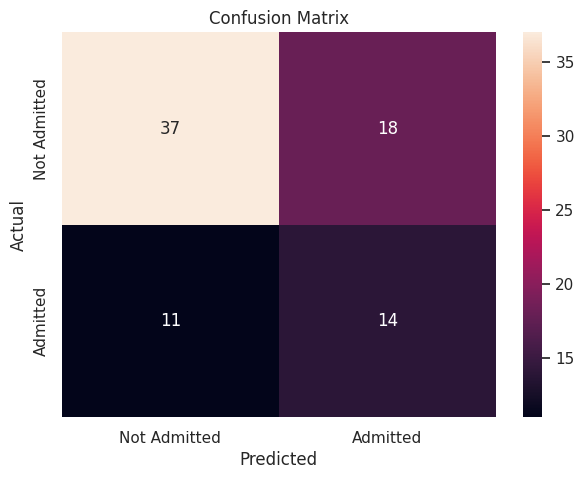

In [48]:
# ============================================
# 18. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Admitted", "Admitted"],
    yticklabels=["Not Admitted", "Admitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [49]:
# ============================================
# 19. MODEL EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 45)
print("       LOGISTIC REGRESSION RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("=" * 45)


       LOGISTIC REGRESSION RESULTS
Accuracy  : 0.6375
Precision : 0.4375
Recall    : 0.5600
F1 Score  : 0.4912


In [50]:
# ============================================
# 20. CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Admitted", "Admitted"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

Not Admitted       0.77      0.67      0.72        55
    Admitted       0.44      0.56      0.49        25

    accuracy                           0.64        80
   macro avg       0.60      0.62      0.60        80
weighted avg       0.67      0.64      0.65        80



In [51]:
# ============================================
# 21. MODEL COEFFICIENTS
# ============================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

display(coefficients)

print("Intercept:", model.intercept_[0])


,Feature,Coefficient
0,gre,0.263671
1,gpa,0.331949
2,rank,-0.415011


Intercept: -0.08431103750051196


In [52]:
# ============================================
# 22. ACTUAL VS PREDICTED
# ============================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison = comparison.reset_index(drop=True)

display(comparison.head(20))

,Actual,Predicted
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,1.0,0.0
5,0.0,1.0
6,1.0,0.0
7,1.0,1.0
8,0.0,0.0
9,1.0,0.0


## Conclusion

A Logistic Regression model was successfully developed to predict
graduate-school admission using GRE score, GPA, and university rank.

The provided Stata (.dta) dataset was loaded and explored. The relevant
features, namely GRE score, GPA, and university rank, were selected as
independent variables, while admission status was used as the target
variable.

The dataset was divided into training and testing sets, and a Logistic
Regression model was trained on the training data.

The model was evaluated using a confusion matrix, Accuracy, Precision,
Recall, and F1 Score.

Thus, Logistic Regression was successfully applied to predict whether
a student would be admitted to graduate school.